### Njihalo

Za sustav koji opisuje njihalo
$$
\begin{align*}
\dot{x_1} & = x_2 \\
\dot{x_2} & = - \frac{g}{l} \sin x_1 - \frac{k}{m} x_2
\end{align*}
$$
konstruirali smo Ljapunovljevu funkciju
$$ V(x) = \frac{1}{2} x^\top P x + \frac{g}{l} (1- \cos x_1),
\quad P = \begin{bmatrix}
\frac{1}{2} \left( \frac{k}{m}  \right)^2 & \frac{1}{2} \frac{k}{m}  \\ \frac{1}{2} \frac{k}{m}  & 1
\end {bmatrix}.$$
Parametri su $g, k, l, m \in [0,\infty\rangle $.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
def odePendulum(t, x, parameters):
    """
    Model njihala prema danim jednadžbama:
    x = [x1, x2] gdje je x1 = theta (kut), x2 = dtheta/dt (kutna brzina)
    parameters = {'g': gravitacijska konstanta, 'l': dužina, 'k': koeficijent prigušenja, 'm': masa}

    Jednadžbe:
    dx1/dt = x2
    dx2/dt = - (g/l) * sin(x1) - (k/m) * x2
    """
    x1, x2 = x
    g = parameters.get('g', 9.81)
    l = parameters.get('l', 1.0)
    k = parameters.get('k', 0.1)
    m = parameters.get('m', 1.0)

    dx1_dt = x2
    dx2_dt = - (g / l) * np.sin(x1) - (k / m) * x2

    return [dx1_dt, dx2_dt]


def LyapunovPendulum(x, parameters):
    """
    Ljapunovljeva funkcija prema danoj formuli:
    V(x) = (1/2) x^T P x + (g/l)(1 - cos(x1))

    gdje je P = [ (1/2)(k/m)^2    (1/2)(k/m) ]
               [ (1/2)(k/m)        1         ]
    """
    x1, x2 = x
    g = parameters.get('g', 9.81)
    l = parameters.get('l', 1.0)
    k = parameters.get('k', 0.1)
    m = parameters.get('m', 1.0)

    # Matrica P
    km_ratio = k / m
    P = np.array([
        [0.5 * km_ratio**2, 0.5 * km_ratio],
        [0.5 * km_ratio, 1.0]
    ])

    # Kvadratni oblik (1/2) x^T P x
    x_vec = np.array([x1, x2])
    quadratic_term = 0.5 * x_vec.T @ P @ x_vec

    # Dodatni član (g/l)(1 - cos(x1))
    potential_term = (g / l) * (1 - np.cos(x1))

    V = quadratic_term + potential_term

    return V

In [3]:
# Parametri za njihalo
params = {'g': 9.81, 'l': 1.0, 'k': 0.1, 'm': 1.0}

# Kreiraj mrežu za vizualizaciju Ljapunovljeve funkcije
x1_vals = np.linspace(-np.pi, np.pi, 50)
x2_vals = np.linspace(-np.pi, np.pi, 50)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# Izračunaj vrijednosti Ljapunovljeve funkcije
V_vals = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        V_vals[i, j] = LyapunovPendulum([X1[i, j], X2[i, j]], params)

# Riješi sustav za početni uvjet (1,1)
x0 = [1.0, 1.0]
t_span = (0, 20)
t_eval = np.linspace(0, 20, 1000)
solution = solve_ivp(lambda t, x: odePendulum(t, x, params), t_span, x0, t_eval=t_eval, rtol=1e-9, atol=1e-12)

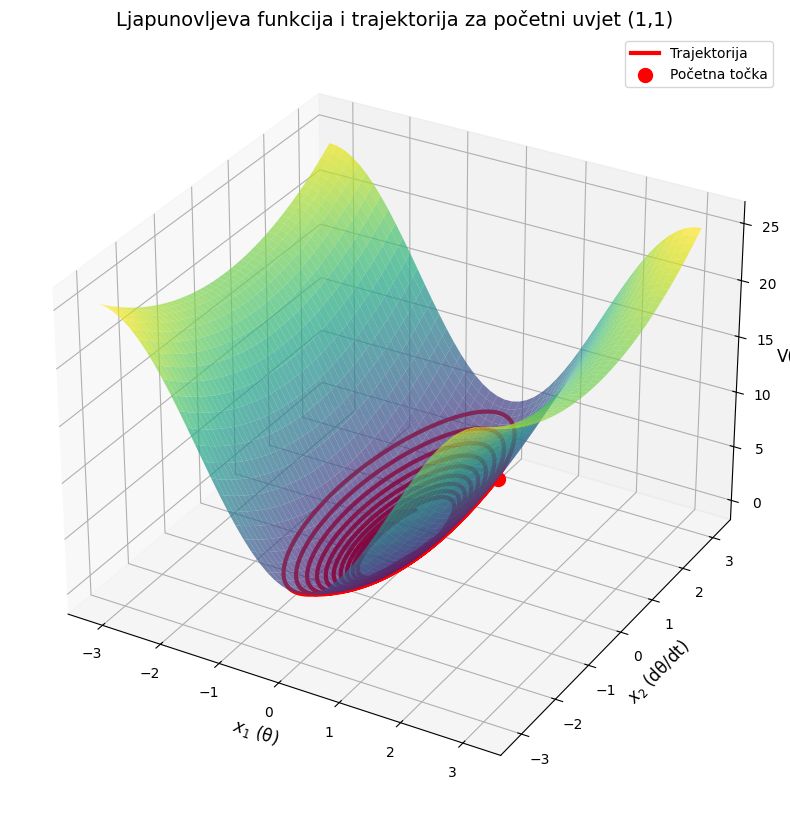

In [4]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
fig.set_figheight(10)
fig.set_figwidth(10)
ax.plot_surface(X1, X2, V_vals, cmap='viridis', alpha=0.7, edgecolor='none')
V_trajectory = np.array([LyapunovPendulum([solution.y[0][k], solution.y[1][k]], params) for k in range(len(solution.y[0]))])
ax.plot(solution.y[0], solution.y[1], V_trajectory, 'r-', linewidth=3, label='Trajektorija')
ax.scatter([x0[0]], [x0[1]], [LyapunovPendulum(x0, params)], color='red', s=100, label='Početna točka')
ax.set_xlabel('$x_1$ (θ)', fontsize=12)
ax.set_ylabel('$x_2$ (dθ/dt)', fontsize=12)
ax.set_zlabel('V(x)', fontsize=12)
ax.set_title('Ljapunovljeva funkcija i trajektorija za početni uvjet (1,1)', fontsize=14)
ax.legend()

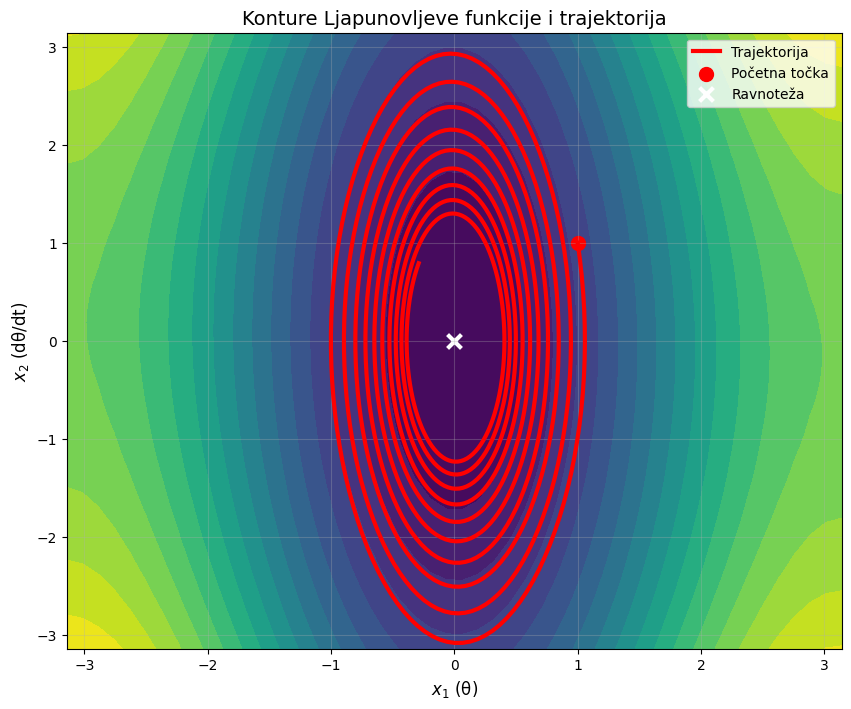

In [5]:
# 2D konturni plot
fig2, ax2 = plt.subplots(figsize=(10, 8))
ax2.contourf(X1, X2, V_vals, levels=20, cmap='viridis')
ax2.plot(solution.y[0], solution.y[1], 'r-', linewidth=3, label='Trajektorija')
ax2.scatter([x0[0]], [x0[1]], color='red', s=100, label='Početna točka')
ax2.scatter([0], [0], color='white', s=100, marker='x', linewidth=3, label='Ravnoteža')

ax2.set_xlabel('$x_1$ (θ)', fontsize=12)
ax2.set_ylabel('$x_2$ (dθ/dt)', fontsize=12)
ax2.set_title('Konture Ljapunovljeve funkcije i trajektorija', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()